# MLP feedforward bagging ensemble

En esta notebook se hace bagging! yupi!

In [2]:
from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from scripts import style
style.mpl_apply()

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from dataclasses import dataclass
import copy
import random
import math

import numpy as np
import pandas as pd


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score

from torch.utils.data import TensorDataset, DataLoader


# Reproducibility
SEED = 246
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

# Load the data

In [3]:
DATA_PATH = Path("09 features/redes_local/datos/processed/df.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (200, 57)


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,pct_bright_block_2_2,H_shannon,center_mean_ratio,center_bright_ratio,lum_centroid_x,lum_centroid_y,filename,painter,genre,label
0,102.20103,105.277170,106.873116,32.077003,33.305286,33.510914,0.0,0.0,0.0,186.0,...,0.195138,-1419.565426,1.198618,1.749636,0.486834,-0.154286,Alfred_Sisley_1.jpg,Alfred_Sisley,Impresionismo,4
1,123.62030,136.959850,149.195050,46.771084,43.979904,49.263435,0.0,0.0,0.0,255.0,...,0.098290,-1419.565426,1.061136,0.937835,0.502996,-0.188640,Alfred_Sisley_10.jpg,Alfred_Sisley,Impresionismo,4
2,118.90262,116.895996,108.091415,48.649280,52.237015,61.140570,0.0,0.0,0.0,255.0,...,0.117654,-1419.489874,0.852622,1.311007,0.504956,-0.304950,Alfred_Sisley_11.jpg,Alfred_Sisley,Impresionismo,4
3,133.78065,140.773590,146.314380,36.072636,36.483162,50.136950,4.0,4.0,0.0,255.0,...,0.018207,-1419.565426,1.091522,1.702214,0.500399,-0.215292,Alfred_Sisley_12.jpg,Alfred_Sisley,Impresionismo,4
4,107.30281,108.520706,92.723560,32.748276,32.094944,37.935650,0.0,0.0,0.0,229.0,...,0.020639,-1419.565426,1.132043,2.128325,0.506062,-0.137083,Alfred_Sisley_13.jpg,Alfred_Sisley,Impresionismo,4


In [4]:
# Encode painters
painter_names = sorted(df["painter"].unique())
painter_to_idx = {name: i for i, name in enumerate(painter_names)}
idx_to_painter = {i: name for name, i in painter_to_idx.items()}

df["painter_idx"] = df["painter"].map(painter_to_idx)

NUM_PAINTERS = len(painter_names)

# Labels (movement / genre index)
# Assume df["label"] is already integer-coded per genre
NUM_LABELS = df["label"].nunique()

# Derive genre names per label (sorted by label index)
label_to_genre = (
    df.drop_duplicates("label")
      .sort_values("label")
      .set_index("label")["genre"]
      .to_dict()
)
class_names = [label_to_genre[i] for i in range(NUM_LABELS)]

print("Painters:", painter_names)
print("NUM_PAINTERS:", NUM_PAINTERS)
print("NUM_LABELS:", NUM_LABELS)
print("Labels → genres:", label_to_genre)


Painters: ['Alfred_Sisley', 'Camille_Pissarro', 'Caravaggio', 'Claude_Monet', 'Jackson_Pollock', 'Joan_Miro', 'Pablo_Picasso', 'Rembrandt', 'Rene_Magritte', 'Salvador_Dali', 'Vincent_van_Gogh']
NUM_PAINTERS: 11
NUM_LABELS: 5
Labels → genres: {0: 'Surrealismo', 1: 'Cubismo', 2: 'Expresionismo abstracto', 3: 'Barroco', 4: 'Impresionismo'}


In [5]:
meta_cols = ["filename", "painter", "genre", "label", "painter_idx"]

feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].to_numpy(dtype=np.float32)
y_painter = df["painter_idx"].to_numpy(dtype=np.int64)
y_label   = df["label"].to_numpy(dtype=np.int64)

print("X shape:", X.shape)
print("y_painter shape:", y_painter.shape)
print("y_label shape:", y_label.shape)
print("Painter counts:", np.bincount(y_painter))
print("Label counts:",   np.bincount(y_label))


X shape: (200, 53)
y_painter shape: (200,)
y_label shape: (200,)
Painter counts: [20 10 10 30 15 20 30 20 10 20 15]
Label counts: [50 30 15 30 75]


# Train Set and Validation Set

In [6]:
X_train, X_val, y_p_train, y_p_val = train_test_split(
    X,
    y_painter,
    test_size=0.1,           # e.g. 80% train / 20% val
    stratify=y_painter,      # stratify by painter (since painter is first task)
    random_state=SEED,
)

print("Train X:", X_train.shape)
print("Val   X:", X_val.shape)


Train X: (180, 53)
Val   X: (20, 53)


## Scaling

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

In [8]:
BATCH_SIZE = 32

X_train_t = torch.from_numpy(X_train_scaled).float()
y_p_train_t = torch.from_numpy(y_p_train).long()

X_val_t = torch.from_numpy(X_val_scaled).float()
y_p_val_t = torch.from_numpy(y_p_val).long()

train_ds = TensorDataset(X_train_t, y_p_train_t)
val_ds   = TensorDataset(X_val_t,   y_p_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(val_loader)


(6, 1)

## Weights

In [9]:
painter_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_PAINTERS),
    y=y_p_train,
)

print("Painter class weights:", painter_class_weights)

painter_class_weights_t = torch.tensor(painter_class_weights, dtype=torch.float32, device=device)

Painter class weights: [0.90909091 1.81818182 1.81818182 0.60606061 1.25874126 0.90909091
 0.60606061 0.90909091 1.81818182 0.90909091 1.16883117]


# Architectures

## MLP

In [10]:
class PainterMLP_Slim(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        bottleneck: int = 16,
        hidden_first: int = 32,
        dropout_p: float = 0.5,
    ):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.BatchNorm1d(hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_first, bottleneck),
            nn.Tanh(),
            nn.Dropout(dropout_p),
        )
        self.head = nn.Linear(bottleneck, num_painters)

    def forward(self, x):
        h = self.trunk(x)
        return self.head(h)


def make_model(hp, input_dim, num_painters, device):
    return PainterMLP_Slim(
        input_dim=input_dim,
        num_painters=num_painters,
        bottleneck=hp["bottleneck"],
        hidden_first=hp["hidden_first"],
        dropout_p=hp["dropout_p"],
    ).to(device)

# Training

## Criterion

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WeightedCrossEntropy(nn.Module):
    def __init__(self, class_weights: torch.Tensor):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, logits, targets):
        return self.ce(logits, targets)


class WeightedLabelSmoothingCE(nn.Module):
    def __init__(self, class_weights: torch.Tensor, smoothing: float = 0.1):
        super().__init__()
        self.class_weights = class_weights
        self.smoothing = smoothing

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        C = logits.size(1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (C - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        w = self.class_weights[targets].unsqueeze(1)  # (B,1)
        loss = -(w * true_dist * log_probs).sum(dim=1).mean()
        return loss


class WeightedFocalLoss(nn.Module):
    def __init__(self, class_weights: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.class_weights = class_weights
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.class_weights, reduction="none")
        pt = torch.exp(-ce)
        focal = ((1.0 - pt) ** self.gamma) * ce
        return focal.mean()


def make_criterion(name: str, class_weights: torch.Tensor, smoothing=0.1, gamma=2.0):
    if name == "wce":
        return WeightedCrossEntropy(class_weights)
    if name == "wce_ls":
        return WeightedLabelSmoothingCE(class_weights, smoothing=smoothing)
    if name == "wfocal":
        return WeightedFocalLoss(class_weights, gamma=gamma)
    raise ValueError(f"Unknown criterion: {name}")

## Train

In [12]:

def train_one_epoch_painter(model, loader, optimizer, criterion, device):
    model.train()
    total, sum_loss = 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        sum_loss += loss.item() * xb.size(0)
        total += xb.size(0)
    return sum_loss / total


@torch.no_grad()
def eval_fold_painter(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        y_pred.append(logits.argmax(1).cpu().numpy())
        y_true.append(yb.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


def fit_and_score_fold_painter(
    X_tr, y_tr,
    X_va, y_va,
    hp,
    input_dim,
    num_painters,
    device,
    max_epochs=40,
    patience=8,
    batch_size=32,
    verbose=False,
):
    # scale per fold
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    # tensors
    X_tr_t = torch.from_numpy(X_tr_s).float()
    y_tr_t = torch.from_numpy(y_tr).long()
    X_va_t = torch.from_numpy(X_va_s).float()
    y_va_t = torch.from_numpy(y_va).long()

    # loaders
    tr_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                           batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TensorDataset(X_va_t, y_va_t),
                           batch_size=batch_size, shuffle=False)

    # class weights on train fold
    w = compute_class_weight("balanced", classes=np.arange(num_painters), y=y_tr)
    w_t = torch.tensor(w, dtype=torch.float32, device=device)

    criterion = make_criterion(
        hp["criterion"],
        w_t,
        smoothing=hp.get("smoothing", 0.1),
        gamma=hp.get("gamma", 2.0),
    )

    model = make_model(hp, input_dim, num_painters, device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    best_state = None
    best_f1 = -np.inf
    best_acc = 0.0
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch_painter(model, tr_loader, optimizer, criterion, device)
        y_t, y_hat = eval_fold_painter(model, va_loader, device)

        val_f1  = f1_score(y_t, y_hat, average="macro")
        val_acc = accuracy_score(y_t, y_hat)

        if verbose:
            print(
                f"    epoch {epoch:02d} | train_loss={train_loss:.4f} | "
                f"val_f1_macro={val_f1:.3f} | val_acc={val_acc:.3f}"
            )

        if val_f1 > best_f1 + 1e-4:
            best_f1 = val_f1
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_f1, best_acc


## Best hyperparameters

In [13]:
# best_h={'bottleneck': 24, 'hidden_first': 32, 'dropout_p': 0.4, 'lr': 0.0024555426586822136, 'weight_decay': 4.070640977962409e-05, 'criterion': np.str_('wce_ls'), 'smoothing': 0.1}
best_h={'bottleneck': 32, 'hidden_first': 128, 'dropout_p': 0.2, 'lr': 0.006, 'weight_decay': 0.0009, 'criterion': np.str_('wce')}
best_h2 ={'bottleneck': 16, 'hidden_first': 64, 'dropout_p': 0.4, 'lr': 0.001825327927769054, 'weight_decay': 0.0002643899253700952, 'criterion': np.str_('wce')}
best_h3 = {'bottleneck': 24, 'hidden_first': 64, 'dropout_p': 0.3, 'lr': 0.0007250757724019477, 'weight_decay': 5.564561032377747e-06, 'criterion': np.str_('wce')}
best_h4 = {'bottleneck': 16, 'hidden_first': 32, 'dropout_p': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'criterion': np.str_('wce')}

## Training

In [14]:
input_dim = X.shape[1]

def make_model(hp):
    return PainterMLP_Slim(
        input_dim=input_dim,
        num_painters=NUM_PAINTERS,
        bottleneck=hp["bottleneck"],
        hidden_first=hp["hidden_first"],
        dropout_p=hp["dropout_p"],
    ).to(device)

In [15]:
LR = best_h["lr"]
WEIGHT_DECAY = best_h["weight_decay"]

painter_criterion = make_criterion(
    name=best_h["criterion"],
    class_weights=painter_class_weights_t,
    smoothing=best_h.get("smoothing", 0.1),
)

In [16]:
K = 12
MAX_EPOCHS = 1000
PATIENCE = 250

In [17]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    painter_criterion,
    device,
):
    model.train()
    total = 0
    sum_loss = 0.0
    correct_painter = 0

    for X_batch, y_p_batch in loader:  
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)

        optimizer.zero_grad()
        painter_logits = model(X_batch) 

        painter_loss = painter_criterion(painter_logits, y_p_batch)

        painter_loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        sum_loss += painter_loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        correct_painter += (painter_pred == y_p_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    return epoch_loss, painter_acc


@torch.no_grad()
def evaluate(
    model,
    loader,
    painter_criterion,
    device,
):
    model.eval()
    total = 0
    sum_loss = 0.0
    correct_painter = 0

    for X_batch, y_p_batch in loader:
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)

        painter_logits = model(X_batch)

        painter_loss = painter_criterion(painter_logits, y_p_batch)

        batch_size = X_batch.size(0)
        sum_loss += painter_loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        correct_painter += (painter_pred == y_p_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    return epoch_loss, painter_acc


In [18]:
import numpy as np
import random
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score


def train_one_epoch_painter(model, loader, optimizer, criterion, device):
    model.train()
    total, sum_loss = 0, 0.0
    y_true_all, y_pred_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        sum_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        y_true_all.append(yb.detach().cpu().numpy())
        y_pred_all.append(logits.argmax(1).detach().cpu().numpy())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    epoch_loss = sum_loss / total
    epoch_acc  = accuracy_score(y_true_all, y_pred_all)
    epoch_f1   = f1_score(y_true_all, y_pred_all, average="macro")

    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate_painter(model, loader, criterion, device):
    model.eval()
    total, sum_loss = 0, 0.0
    y_true_all, y_pred_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        sum_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        y_true_all.append(yb.cpu().numpy())
        y_pred_all.append(logits.argmax(1).cpu().numpy())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    epoch_loss = sum_loss / total
    epoch_acc  = accuracy_score(y_true_all, y_pred_all)
    epoch_f1   = f1_score(y_true_all, y_pred_all, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

In [19]:
import numpy as np
import random
import copy

def train_single_model_with_history(
    seed: int,
    max_epochs: int = 40,
    patience: int = 8,
    best_h: dict = None,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # 1) model from best hyperparams
    model = make_model(best_h).to(device)

    # 2) optimizer from best hyperparams
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(best_h["lr"]),
        weight_decay=float(best_h["weight_decay"]),
    )

    try:
        # prefer global tensor if exists
        painter_weights_t = painter_class_weights_t
    except NameError:
        # otherwise compute from y_p_train
        w = compute_class_weight(
            class_weight="balanced",
            classes=np.arange(NUM_PAINTERS),
            y=y_p_train,
        )
        painter_weights_t = torch.tensor(w, dtype=torch.float32, device=device)

    painter_criterion = make_criterion(
        best_h["criterion"],
        painter_weights_t,
        smoothing=float(best_h.get("smoothing", 0.1)),
        gamma=float(best_h.get("gamma", 2.0)),
    )

    history = {
        "train_loss": [],
        "train_painter_acc": [],
        "train_painter_f1": [],
        "val_loss": [],
        "val_painter_acc": [],
        "val_painter_f1": [],
    }

    best_state = None
    best_val_f1 = -np.inf
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch_painter(
            model,
            train_loader,
            optimizer,
            painter_criterion,
            device,
        )

        val_loss, val_acc, val_f1 = evaluate_painter(
            model,
            val_loader,
            painter_criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["train_painter_acc"].append(train_acc)
        history["train_painter_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_painter_acc"].append(val_acc)
        history["val_painter_f1"].append(val_f1)

        print(
            f"[seed {seed}] epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, train_f1={train_f1:.3f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}, val_f1={val_f1:.3f}"
        )

        # early stop on macro-F1 (matches CV selection)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[seed {seed}] Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_f1


In [20]:
models, histories, scores = [], [], []

for k in range(K):
    seed_k = SEED + k
    # best_h = [best_h, best_h2, best_h3, best_h4][k % 4]  # cycle through best hyperparams
    print(f"\n=== Training model {k+1}/{K} (seed={seed_k}) ===")
    model_k, hist_k, score_k = train_single_model_with_history(
        seed=seed_k,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE, 
        best_h=best_h
    )
    models.append(model_k)
    histories.append(hist_k)
    scores.append(score_k)

print("Val painter acc of each model:", scores)
print("Mean:", np.mean(scores), "Std:", np.std(scores))



=== Training model 1/12 (seed=246) ===
[seed 246] epoch 01 | train_loss=2.2206, train_acc=0.194, train_f1=0.174 | val_loss=2.0146, val_acc=0.300, val_f1=0.149
[seed 246] epoch 02 | train_loss=1.7772, train_acc=0.433, train_f1=0.397 | val_loss=1.7828, val_acc=0.300, val_f1=0.171
[seed 246] epoch 03 | train_loss=1.5225, train_acc=0.517, train_f1=0.499 | val_loss=1.6711, val_acc=0.350, val_f1=0.255
[seed 246] epoch 04 | train_loss=1.3918, train_acc=0.567, train_f1=0.554 | val_loss=1.6205, val_acc=0.300, val_f1=0.227
[seed 246] epoch 05 | train_loss=1.2086, train_acc=0.639, train_f1=0.626 | val_loss=1.5724, val_acc=0.400, val_f1=0.342
[seed 246] epoch 06 | train_loss=1.1070, train_acc=0.650, train_f1=0.656 | val_loss=1.5352, val_acc=0.400, val_f1=0.346
[seed 246] epoch 07 | train_loss=0.9929, train_acc=0.694, train_f1=0.701 | val_loss=1.4305, val_acc=0.500, val_f1=0.461
[seed 246] epoch 08 | train_loss=0.8187, train_acc=0.717, train_f1=0.725 | val_loss=1.3840, val_acc=0.600, val_f1=0.606


# Training Visualization

In [21]:
best_idx = int(np.argmax(scores))
best_history = histories[best_idx]
print("Best model index:", best_idx)

Best model index: 8


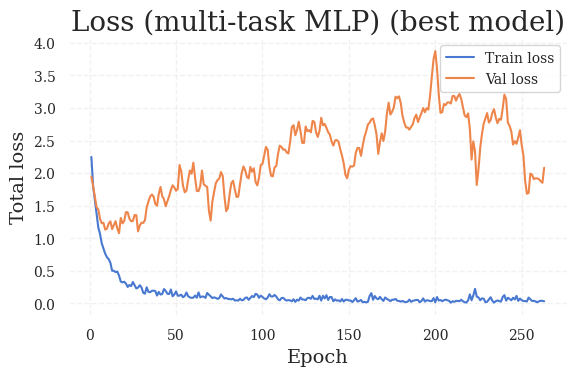

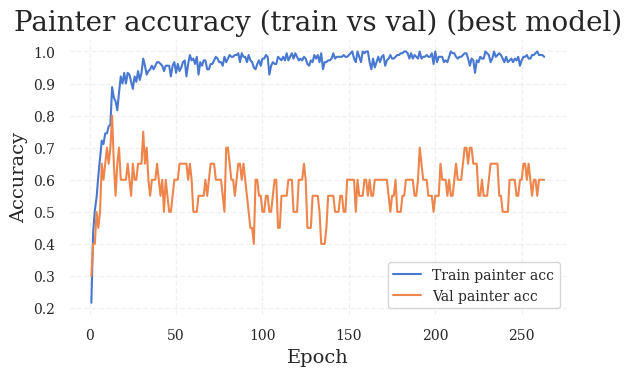

In [24]:
import matplotlib.pyplot as plt

def plot_history_one(history, title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"],   label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Total loss")
    plt.title(f"Loss (multi-task MLP){title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Painter accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_painter_acc"], label="Train painter acc")
    plt.plot(epochs, history["val_painter_acc"],   label="Val painter acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Painter accuracy (train vs val){title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
plot_history_one(histories[8], title_suffix=" (best model)")


# Validation

In [25]:
# painter -> genre (take the most frequent genre per painter to be safe)
painter_to_genre = (
    df.groupby("painter")["genre"]
      .agg(lambda s: s.mode().iloc[0])   # mode handles any accidental duplicates
      .to_dict()
)

# optional: genre -> label (again mode-safe)
genre_to_label = (
    df.groupby("genre")["label"]
      .agg(lambda s: s.mode().iloc[0])
      .to_dict()
)

print(painter_to_genre)
print(genre_to_label)


{'Alfred_Sisley': 'Impresionismo', 'Camille_Pissarro': 'Impresionismo', 'Caravaggio': 'Barroco', 'Claude_Monet': 'Impresionismo', 'Jackson_Pollock': 'Expresionismo abstracto', 'Joan_Miro': 'Surrealismo', 'Pablo_Picasso': 'Cubismo', 'Rembrandt': 'Barroco', 'Rene_Magritte': 'Surrealismo', 'Salvador_Dali': 'Surrealismo', 'Vincent_van_Gogh': 'Impresionismo'}
{'Barroco': 3, 'Cubismo': 1, 'Expresionismo abstracto': 2, 'Impresionismo': 4, 'Surrealismo': 0}


## Bagging Ensemble

In [26]:
import torch
import numpy as np

@torch.no_grad()
def ensemble_predict(models, X_t, device, return_logits=False):
    # accept numpy input
    if isinstance(X_t, np.ndarray):
        X_t = torch.from_numpy(X_t).float()

    X_t = X_t.to(device)

    p_logits_sum = None

    for model in models:
        model.eval()
        p_logits = model(X_t)
        p_logits_sum = p_logits if p_logits_sum is None else p_logits_sum + p_logits

    # average
    p_logits_mean = p_logits_sum / len(models)
    y_p_pred = p_logits_mean.argmax(dim=1).cpu().numpy()

    if return_logits:
        return y_p_pred, p_logits_mean
    return y_p_pred


In [28]:
# If needed: recompute painter ensemble preds on val
y_p_true = y_p_val_t.numpy()

y_p_pred_ens = ensemble_predict(models, X_val_t, device)  # painter-only ensemble

## Translate to labels

In [29]:
# painter index -> painter name
p_true_names = [idx_to_painter[i] for i in y_p_true]
p_pred_names = [idx_to_painter[i] for i in y_p_pred_ens]

# painter name -> genre
g_true_names = [painter_to_genre[p] for p in p_true_names]
g_pred_names = [painter_to_genre.get(p, "UNKNOWN") for p in p_pred_names]

g_true_names = np.array(g_true_names)
g_pred_names = np.array(g_pred_names)

print("Genres in eval:", sorted(set(g_true_names) | set(g_pred_names)))


Genres in eval: [np.str_('Barroco'), np.str_('Cubismo'), np.str_('Expresionismo abstracto'), np.str_('Impresionismo'), np.str_('Surrealismo')]


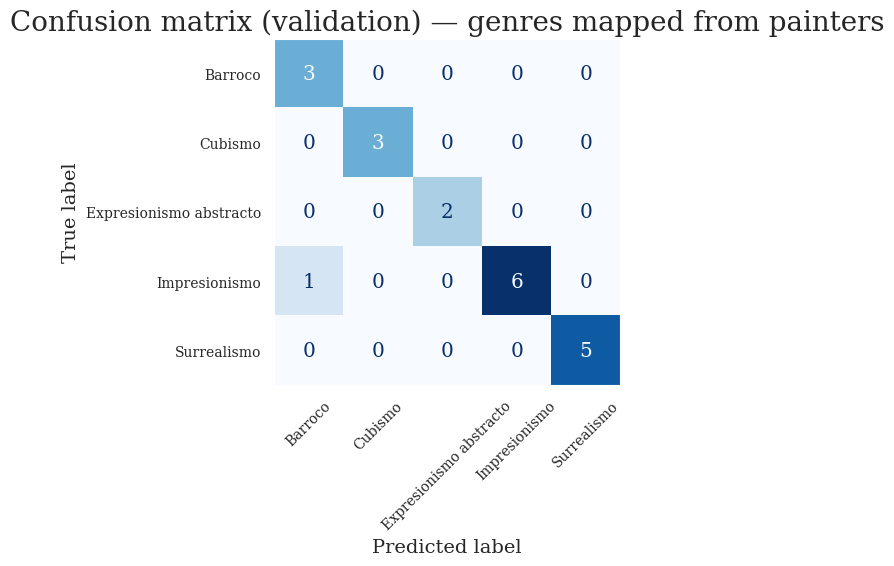

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

genre_classes = sorted(df["genre"].unique())  # uses your train df
genre_to_idx = {g:i for i,g in enumerate(genre_classes)}

g_true = np.array([genre_to_idx[g] for g in g_true_names])
g_pred = np.array([genre_to_idx[g] for g in g_pred_names])

cm = confusion_matrix(g_true, g_pred, labels=np.arange(len(genre_classes)))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genre_classes)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) — genres mapped from painters")
plt.tight_layout()
plt.grid(False)
plt.show()


In [31]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, balanced_accuracy_score

acc  = accuracy_score(g_true, g_pred)
bacc = balanced_accuracy_score(g_true, g_pred)
f1_macro = f1_score(g_true, g_pred, average="macro")
f1_weighted = f1_score(g_true, g_pred, average="weighted")

print(f"Genre accuracy        : {acc:.3f}")
print(f"Genre balanced acc    : {bacc:.3f}")
print(f"Genre F1 macro        : {f1_macro:.3f}")
print(f"Genre F1 weighted     : {f1_weighted:.3f}\n")

print("Classification report (genres):")
print(classification_report(g_true, g_pred, target_names=genre_classes, digits=3))


Genre accuracy        : 0.950
Genre balanced acc    : 0.971
Genre F1 macro        : 0.956
Genre F1 weighted     : 0.952

Classification report (genres):
                         precision    recall  f1-score   support

                Barroco      0.750     1.000     0.857         3
                Cubismo      1.000     1.000     1.000         3
Expresionismo abstracto      1.000     1.000     1.000         2
          Impresionismo      1.000     0.857     0.923         7
            Surrealismo      1.000     1.000     1.000         5

               accuracy                          0.950        20
              macro avg      0.950     0.971     0.956        20
           weighted avg      0.963     0.950     0.952        20



# Test

In [32]:
TEST_PATH = Path("09 features/redes_local/datos/processed/df_bb.csv")
df_test = pd.read_csv(TEST_PATH)

print("df_test shape:", df_test.shape)
print("df_test cols:", df_test.columns.tolist()[:10], "...")
df_test.head()

df_test shape: (750, 57)
df_test cols: ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'min_R', 'min_G', 'min_B', 'max_R'] ...


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,pct_bright_block_2_2,H_shannon,center_mean_ratio,center_bright_ratio,lum_centroid_x,lum_centroid_y,filename,painter,genre,label
0,113.894936,127.379160,103.34666,53.270428,70.752464,75.454780,0.0,2.0,0.0,255.0,...,0.010783,-1419.565426,0.539663,0.000304,0.553279,-0.467646,Alfred_Sisley_001.jpg,Alfred_Sisley,Impresionismo,4
1,100.800140,91.574240,75.35645,76.134636,75.270805,72.747894,5.0,8.0,0.0,255.0,...,0.000270,-1398.751068,0.634973,0.000000,0.525715,-0.609516,Alfred_Sisley_002.jpg,Alfred_Sisley,Impresionismo,4
2,129.785230,116.044860,89.18722,47.168243,54.259525,42.555046,49.0,28.0,20.0,255.0,...,0.000059,-1419.565426,0.883822,0.285084,0.483567,-0.700687,Alfred_Sisley_003.jpg,Alfred_Sisley,Impresionismo,4
3,119.764275,126.478325,115.54521,55.139767,62.966022,80.313644,10.0,1.0,0.0,255.0,...,0.000000,-1419.537688,0.813258,0.521069,0.492189,-0.565718,Alfred_Sisley_004.jpg,Alfred_Sisley,Impresionismo,4
4,143.549220,138.841380,130.06557,87.223040,88.330170,91.912506,3.0,7.0,0.0,255.0,...,0.000000,-1397.840623,0.514418,0.073863,0.511623,-0.144344,Alfred_Sisley_005.jpg,Alfred_Sisley,Impresionismo,4


In [34]:
X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
X_test_scaled = scaler.transform(X_test)  # IMPORTANT: no fit here

X_test_t = torch.from_numpy(X_test_scaled).float()

In [35]:
y_p_pred_test = ensemble_predict(models, X_test_t, device)  # painter-only models

# painter index -> painter name
painter_pred_names = [idx_to_painter[i] for i in y_p_pred_test]

df_test["painter_pred"] = painter_pred_names
df_test.head()

,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,H_shannon,center_mean_ratio,center_bright_ratio,lum_centroid_x,lum_centroid_y,filename,painter,genre,label,painter_pred
0,113.894936,127.379160,103.34666,53.270428,70.752464,75.454780,0.0,2.0,0.0,255.0,...,-1419.565426,0.539663,0.000304,0.553279,-0.467646,Alfred_Sisley_001.jpg,Alfred_Sisley,Impresionismo,4,Alfred_Sisley
1,100.800140,91.574240,75.35645,76.134636,75.270805,72.747894,5.0,8.0,0.0,255.0,...,-1398.751068,0.634973,0.000000,0.525715,-0.609516,Alfred_Sisley_002.jpg,Alfred_Sisley,Impresionismo,4,Caravaggio
2,129.785230,116.044860,89.18722,47.168243,54.259525,42.555046,49.0,28.0,20.0,255.0,...,-1419.565426,0.883822,0.285084,0.483567,-0.700687,Alfred_Sisley_003.jpg,Alfred_Sisley,Impresionismo,4,Caravaggio
3,119.764275,126.478325,115.54521,55.139767,62.966022,80.313644,10.0,1.0,0.0,255.0,...,-1419.537688,0.813258,0.521069,0.492189,-0.565718,Alfred_Sisley_004.jpg,Alfred_Sisley,Impresionismo,4,Alfred_Sisley
4,143.549220,138.841380,130.06557,87.223040,88.330170,91.912506,3.0,7.0,0.0,255.0,...,-1397.840623,0.514418,0.073863,0.511623,-0.144344,Alfred_Sisley_005.jpg,Alfred_Sisley,Impresionismo,4,Caravaggio


In [36]:
df_test["genre_pred"] = df_test["painter_pred"].map(painter_to_genre)
df_test["label_pred"] = df_test["genre_pred"].map(genre_to_label)  # optional

df_test[["painter_pred", "genre_pred", "label_pred"]].head()

,painter_pred,genre_pred,label_pred
0,Alfred_Sisley,Impresionismo,4
1,Caravaggio,Barroco,3
2,Caravaggio,Barroco,3
3,Alfred_Sisley,Impresionismo,4
4,Caravaggio,Barroco,3


Painter acc (test): 0.444
                  precision    recall  f1-score   support

   Alfred_Sisley      0.392     0.671     0.495        70
Camille_Pissarro      0.595     0.417     0.490        60
      Caravaggio      0.400     0.700     0.509        60
    Claude_Monet      0.494     0.550     0.521        80
 Jackson_Pollock      1.000     0.431     0.602        65
       Joan_Miro      0.806     0.357     0.495        70
   Pablo_Picasso      0.478     0.400     0.435        80
       Rembrandt      0.517     0.429     0.469        70
   Rene_Magritte      0.387     0.200     0.264        60
   Salvador_Dali      0.600     0.386     0.470        70
Vincent_van_Gogh      0.157     0.323     0.211        65

        accuracy                          0.444       750
       macro avg      0.530     0.442     0.451       750
    weighted avg      0.531     0.444     0.453       750



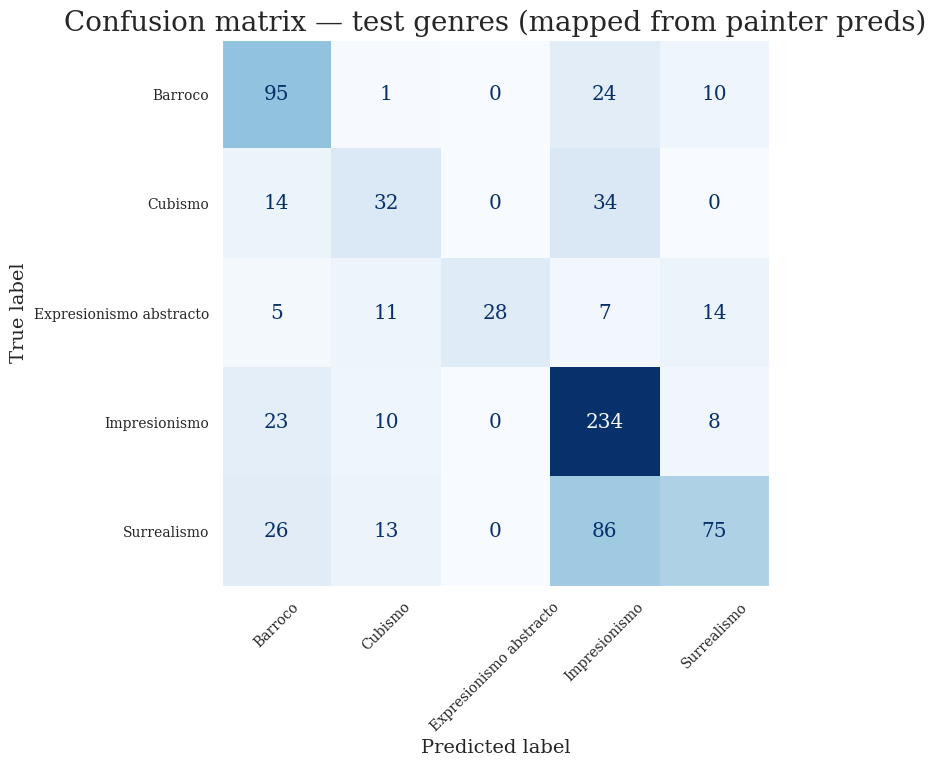

Genre acc (test): 0.6186666666666667
                         precision    recall  f1-score   support

                Barroco      0.583     0.731     0.648       130
                Cubismo      0.478     0.400     0.435        80
Expresionismo abstracto      1.000     0.431     0.602        65
          Impresionismo      0.608     0.851     0.709       275
            Surrealismo      0.701     0.375     0.489       200

               accuracy                          0.619       750
              macro avg      0.674     0.557     0.577       750
           weighted avg      0.648     0.619     0.601       750



In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

has_true_painter = "painter" in df_test.columns
has_true_genre   = "genre"   in df_test.columns

if has_true_painter:
    # painter metrics
    y_true_p = df_test["painter"].map(painter_to_idx).to_numpy()
    y_pred_p = np.array([painter_to_idx[p] for p in df_test["painter_pred"]])

    print("Painter acc (test):", accuracy_score(y_true_p, y_pred_p))
    print(classification_report(y_true_p, y_pred_p, target_names=painter_names, digits=3))

if has_true_genre:
    # genre metrics from mapped preds
    genre_classes = sorted(df["genre"].unique())
    genre_to_idx = {g:i for i,g in enumerate(genre_classes)}

    g_true = df_test["genre"].map(genre_to_idx).to_numpy()
    g_pred = df_test["genre_pred"].map(genre_to_idx).to_numpy()

    cm = confusion_matrix(g_true, g_pred, labels=np.arange(len(genre_classes)))
    disp = ConfusionMatrixDisplay(cm, display_labels=genre_classes)
    disp.plot(cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title("Confusion matrix — test genres (mapped from painter preds)")
    plt.tight_layout()
    plt.grid(False)
    plt.show()

    print("Genre acc (test):", accuracy_score(g_true, g_pred))
    print(classification_report(g_true, g_pred, target_names=genre_classes, digits=3))
